## TODO:  HEADER

In [1]:
%load_ext autoreload
%autoreload 2

import nltk

nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

import umap
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.encoders import *
from utils.preprocess import text_cleaner, pipeline
from utils.utils import visualize_dimensionality_reduction

from lingua import LanguageDetectorBuilder
from deep_translator import GoogleTranslator
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score
from sklearn.model_selection import ParameterSampler

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
STOPWORDS = set(stopwords.words("English")).difference({"up", "down", "above", "below", "under", 
                                                        "over", "more", "less", "against", "but", 
                                                        "not", "no"})
SEED = 42

# EDA

In [3]:
train_full = pd.read_csv(r"data/train.csv")
train, validation = train_test_split(train_full, 
                                     test_size=0.2, 
                                     stratify=train_full.label,
                                     random_state=SEED
                                     )
test = pd.read_csv(r"data/test.csv", index_col=0)
display(train.sample(3))
display(validation.sample(3))
test.sample(3)

,text,label
9525,Stocks making the biggest moves after hours: S...,2
572,Federal Reserve to backstop Payment Protection...,2
5201,The Growth of Private Debt markets,2


,text,label
3233,Spot prices for crude oil are little changed i...,2
8461,Did Hedge Funds Drop The Ball On Intra-Cellula...,2
6839,Nasdaq at record high as investors look past c...,1


,text
id,
1290,"RMR Group EPS beats by $0.01, beats on revenue"
150,Canada's TD Beats Its U.S. Banking Competitors...
1369,$KTOS: Kratos Defense and Security awarded a $...


## general

In [4]:
display(train.describe())
train.describe(include="str")

,label
count,7634.000000
mean,1.496201
std,0.743229
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,2.000000


,text
count,7634
unique,7634
top,Nasdaq prices 600M of 0.875% senior notes
freq,1


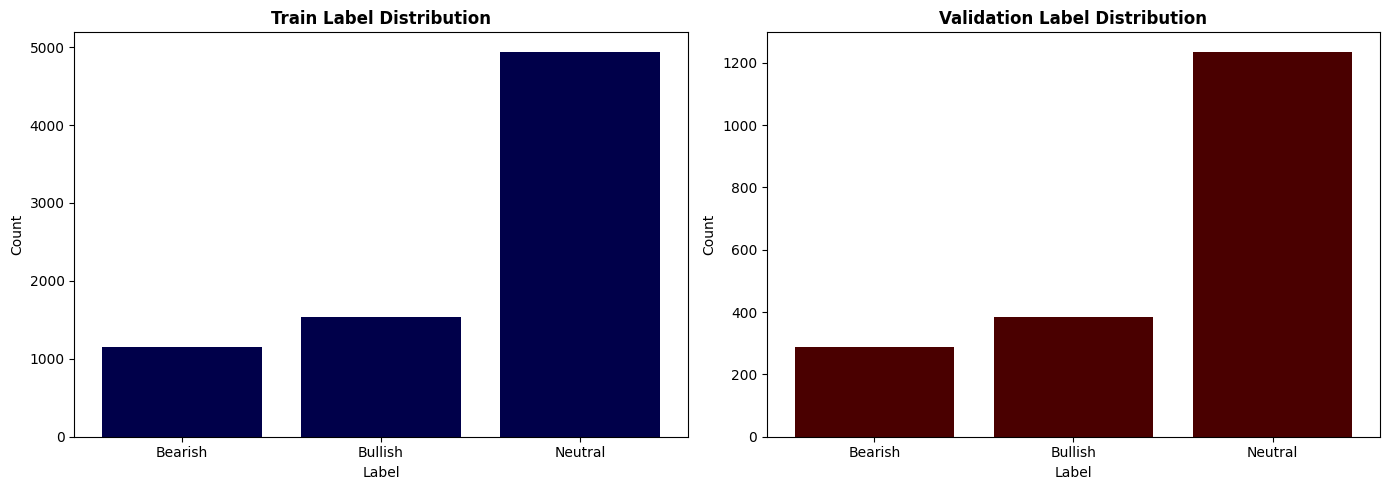

In [5]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=train.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#00004A",
        )

ax[1].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=validation.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#4A0000",
        )

ax[0].set_xlabel("Label")
ax[0].set_ylabel("Count")
ax[0].set_title(
    "Train Label Distribution", fontweight="bold"
)

ax[1].set_xlabel("Label")
ax[1].set_ylabel("Count")
ax[1].set_title(
    "Validation Label Distribution", fontweight="bold"
)

plt.tight_layout()
plt.savefig(r"plots/correct_split.png")
plt.show()

## Text Overview

### Raw

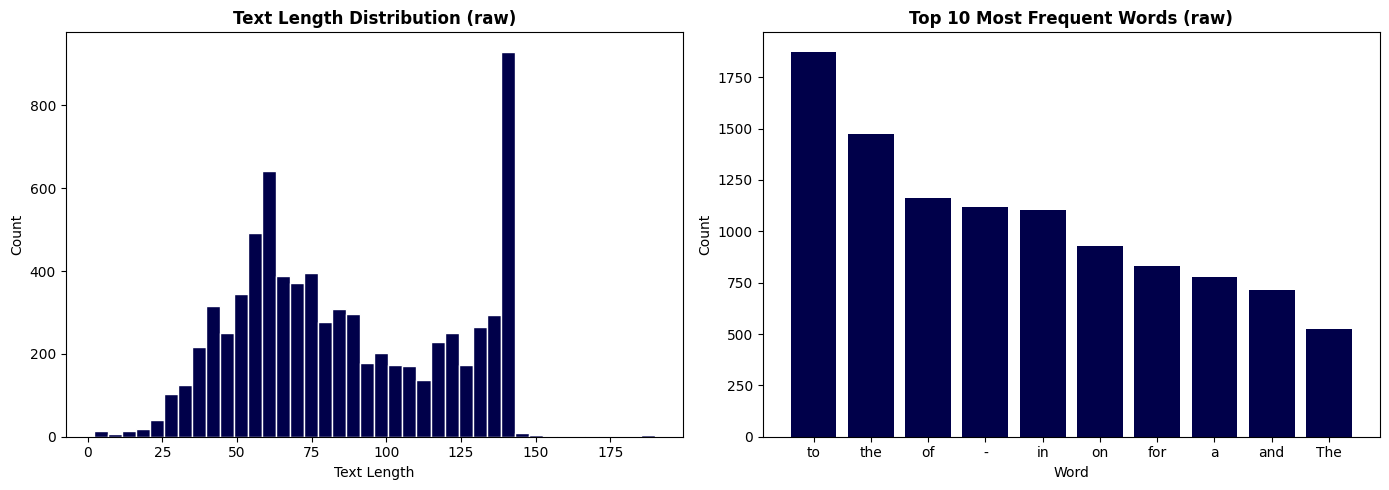

In [6]:
freq_raw = pd.Series(' '.join(train['text']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].hist(
         train.text.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )

ax[1].bar(freq_raw.head(10).index, freq_raw.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (raw)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (raw)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/raw_distributions.png")
plt.show()

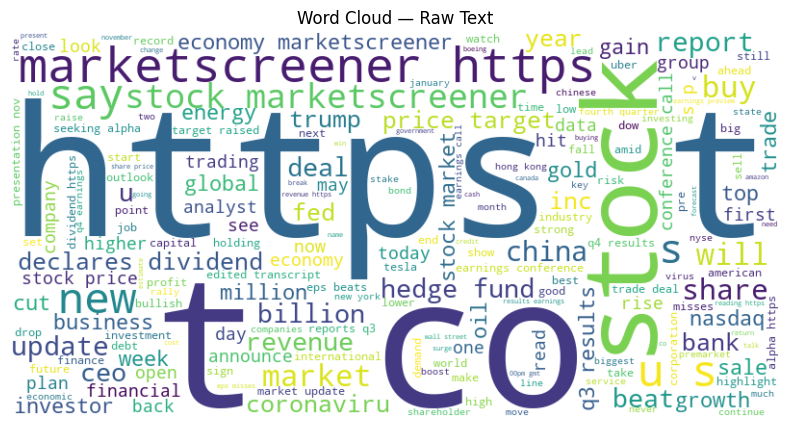

In [7]:
raw_text = ' '.join(train['text']).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Raw Text')
plt.savefig(r"plots/raw_wordcloud.png")
plt.show()

### Cleaning

In [8]:
train["text_clean"] = text_cleaner(train.text)
validation["text_clean"] = text_cleaner(validation.text)

display(train.sample(5))
validation.sample(5)

,text,label,text_clean
3872,U.S. Marriages Rising as Same-Sex Couples Now ...,1,you s marriages rising as same sex couples now...
5960,Aurora Property Buy Write Income Trust : NTA E...,2,aurora property buy write income trust nta est...
3980,100% Correct!,2,100 percent correct
6838,"Most Saudi Arabian banking stocks climbed, eve...",1,most saudi arabian banking stocks climbed even...
5860,Eskom Loses Bid for Higher Tariffs as Court De...,2,eskom loses bid for higher tariffs as court de...


,text,label,text_clean
5801,$DISH $I $SGBAF - Dish spectrum sale shouldn't...,1,STOCK STOCK STOCK dish spectrum sale should no...
3190,February 2020: Natural Gas Supply-Demand Balan...,2,february 2020 natural gas supply demand balanc...
2813,Klabin reports Q4 results,2,klabin reports q4 results
8532,Global Medical REIT adds another bull to its herd,2,global medical reit adds another bull to its herd
3037,U.S. shale gas investors brace for write-downs...,0,you s shale gas investors brace for write down...


In [9]:
detector = LanguageDetectorBuilder.from_all_languages().build()

languages_train = detector.detect_languages_in_parallel_of(train.text_clean)
train["language"] = [lang.name.lower() if lang else None for lang in languages_train]

languages_validation = detector.detect_languages_in_parallel_of(validation.text_clean)
validation["language"] = [lang.name.lower() if lang else None for lang in languages_validation]

non_eng_train = train[train["language"]!="english"]["text_clean"].index.to_list()
non_eng_validation = validation[validation["language"]!="english"]["text_clean"].index.to_list()

train.sample(5)
validation.sample(5)

,text,label,text_clean,language
7693,$T - Irrational Market Drops AT&T Because Of I...,0,STOCK irrational market drops at t because of ...,english
6399,The amount of electricity generated from coal ...,1,the amount of electricity generated from coal ...,english
600,"In ""Unprecedented"" Move To Ease Conditions, EC...",2,in unprecedented move to ease conditions ecb c...,english
6314,Business activity in France picked up slightly...,1,business activity in france picked up slightly...,english
2423,Public Service declares $0.47 dividend,2,public service declares 0 47 dividend,english


In [10]:
# GoogleTranslator sometimes adds symbols on its own, so has to be cleaned again even if use text_clean
# TODO use text_clean or text?

train.loc[non_eng_train, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            train.loc[non_eng_train, "text"].to_list()
                                        )
            )
    ).to_list()

validation.loc[non_eng_validation, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            validation.loc[non_eng_validation, "text"].to_list()
                                        )
            )
    ).to_list()

In [11]:
train["text_tokens"] = pipeline(train["text_clean"], to_clean=False, stopwords_list=STOPWORDS)
validation["text_tokens"] = pipeline(validation["text_clean"], to_clean=False, stopwords_list=STOPWORDS)

Failed to reload module 'utils.encoders' from file 'c:\Users\egorm\classes_notebook\tm_masters\TM_Project_Masters\src\utils\encoders.py'
Traceback (most recent call last):
  File "c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\IPython\extensions\autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\egorm\miniconda3\envs\tm_masters\Lib\importlib\__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "c:\Users\egorm\classes_notebook\tm_masters\TM_Project_Masters\src\utils\encoders.py", line 3, in <module>
    import torch
M

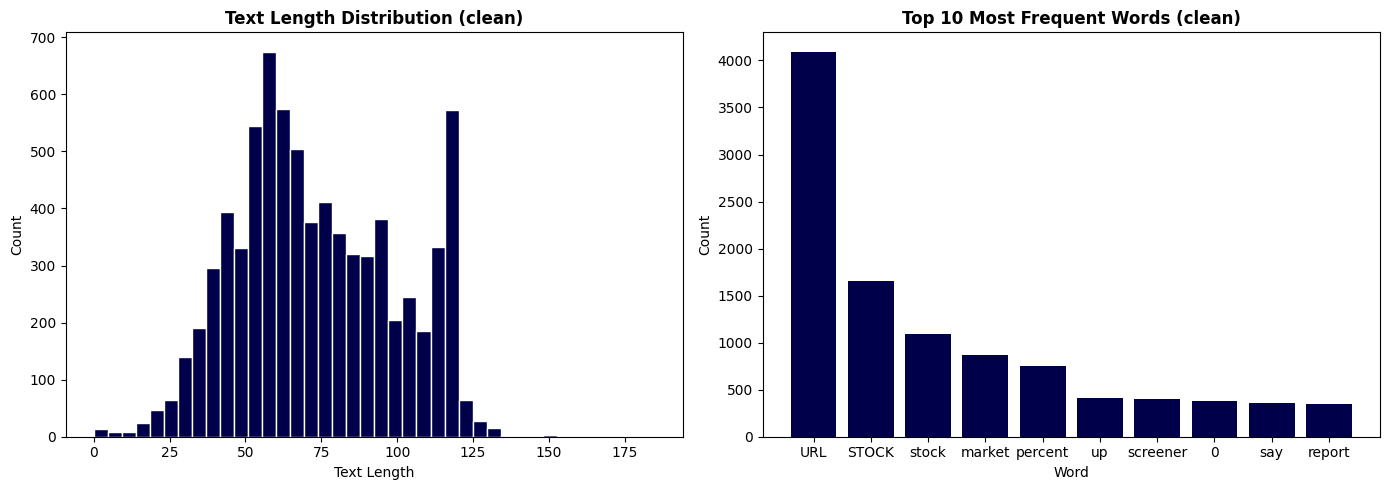

In [12]:
train["text_clean_joined"] = train['text_tokens'].apply(lambda x: " ".join(x))
freq_clean = pd.Series(' '.join(train['text_clean_joined']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))
ax[0].hist(
         train.text_clean.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )
ax[1].bar(freq_clean.head(10).index, freq_clean.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (clean)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (clean)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/clean_distributions.png")
plt.show()

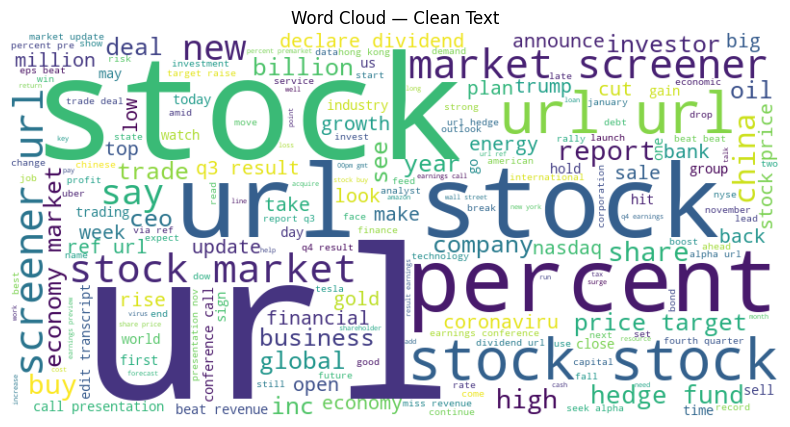

In [13]:
raw_text = ' '.join(train["text_clean_joined"]).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Clean Text')
plt.savefig(r"plots/clean_wordcloud.png")
plt.show()

### Encoding
todo: should there be umap?

In [14]:
train_bow, bow_encoder = encode_bow(train["text_tokens"], min_df=30)

w2v_encoder = train_word2vec_model(train["text_tokens"], vector_size=35)
train_vec = encode_w2v(train["text_tokens"], w2v_encoder)

train_trans = ...

train_label = train["label"]

In [15]:
# this is wrong
validation_bow = encode_bow(validation["text_tokens"], 
                            encoder=bow_encoder, 
                            return_bow=False)
validation_vec = encode_w2v(validation["text_tokens"], w2v_encoder)
validation_trans = ...

validation_label = validation["label"]

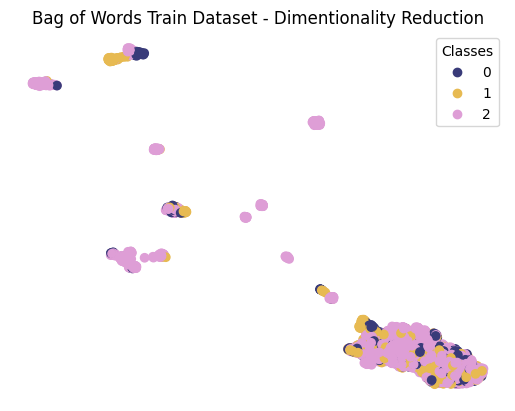

In [16]:
# TODO: save this
umap_object = umap.UMAP(n_neighbors=50, min_dist=0.9, random_state=SEED) 
umap_embedding = umap_object.fit_transform(train_bow)
visualize_dimensionality_reduction(umap_embedding, 
                                   train_label, 
                                   save_to=r"plots/bow_umap.png",
                                   title="Bag of Words Train Dataset - Dimentionality Reduction")

Failed to reload module 'utils.encoders' from file 'c:\Users\egorm\classes_notebook\tm_masters\TM_Project_Masters\src\utils\encoders.py'
Traceback (most recent call last):
  File "c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\IPython\extensions\autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\egorm\miniconda3\envs\tm_masters\Lib\importlib\__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "c:\Users\egorm\classes_notebook\tm_masters\TM_Project_Masters\src\utils\encoders.py", line 3, in <module>
    import torch
M

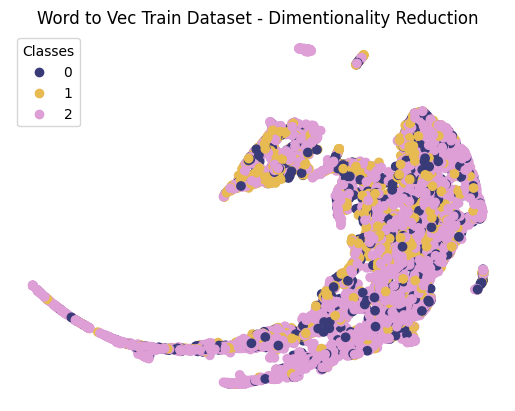

In [17]:
umap_object = umap.UMAP(n_neighbors=50, min_dist=0.1, random_state=SEED) 
umap_embedding = umap_object.fit_transform(train_vec)
visualize_dimensionality_reduction(umap_embedding, 
                                   train_label,
                                   save_to=r"plots/w2v_umap.png",
                                   title="Word to Vec Train Dataset - Dimentionality Reduction")

# Training

## BOW Data

### KNN

In [18]:
best_score = -float("inf")
grid = {
        "n_neighbors": [*range(1, 16, 2)],
        "weights": ["uniform", "distance"],
        "p": [1, 2, 3]
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _knn = KNeighborsClassifier()
    _knn.set_params(**g)
    _knn.fit(train_bow, train_label)

    new_score = recall_score(validation_label, 
                             _knn.predict(validation_bow), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [02:58<00:00,  5.96s/it]

Best Recall: 0.60270
Grid: {'weights': 'distance', 'p': 2, 'n_neighbors': 3}


In [19]:
knn_classifier = KNeighborsClassifier()\
                .set_params(**best_grid)\
                .fit(train_bow, train_label)
knn_predicted = knn_classifier.predict(validation_bow)
knn_cm = confusion_matrix(validation_label, knn_predicted, normalize="true")

print(classification_report(validation_label, 
                            knn_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

Failed to reload module 'utils.encoders' from file 'c:\Users\egorm\classes_notebook\tm_masters\TM_Project_Masters\src\utils\encoders.py'
Traceback (most recent call last):
  File "c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\IPython\extensions\autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\egorm\miniconda3\envs\tm_masters\Lib\importlib\__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "c:\Users\egorm\classes_notebook\tm_masters\TM_Project_Masters\src\utils\encoders.py", line 3, in <module>
    import torch
M

              precision    recall  f1-score   support

     Bearish       0.55      0.39      0.45       288
     Bullish       0.69      0.51      0.59       385
     Neutral       0.79      0.91      0.85      1236

    accuracy                           0.75      1909
   macro avg       0.68      0.60      0.63      1909
weighted avg       0.73      0.75      0.74      1909



### Tree

In [20]:
best_score = -float("inf")
grid = {
        "n_estimators":[*range(10, 251, 10)], 
        "criterion":["gini", "entropy"],
        "max_depth":[*range(1, 11)],
        "min_samples_split":[2**p for p in range(1, 11)],
        "min_samples_leaf":[2**p for p in range(0, 11)],
        "max_features":["sqrt", "log2", 1],
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _rf = RandomForestClassifier()
    _rf.set_params(**g)
    _rf.fit(train_bow, train_label)

    new_score = recall_score(validation_label, 
                             _rf.predict(validation_bow), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [00:13<00:00,  2.30it/s]

Best Recall: 0.38193
Grid: {'n_estimators': 40, 'min_samples_split': 2, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'max_depth': 9, 'criterion': 'entropy'}


In [21]:
rf_classifier = RandomForestClassifier()\
                .set_params(**best_grid)\
                .fit(train_bow, train_label)

rf_predicted = rf_classifier.predict(validation_bow)
rf_cm = confusion_matrix(validation_label, rf_predicted, normalize="true")

print(classification_report(validation_label, 
                            rf_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

              precision    recall  f1-score   support

     Bearish       1.00      0.02      0.05       288
     Bullish       0.87      0.12      0.21       385
     Neutral       0.67      1.00      0.80      1236

    accuracy                           0.67      1909
   macro avg       0.84      0.38      0.35      1909
weighted avg       0.76      0.67      0.57      1909



### Compare

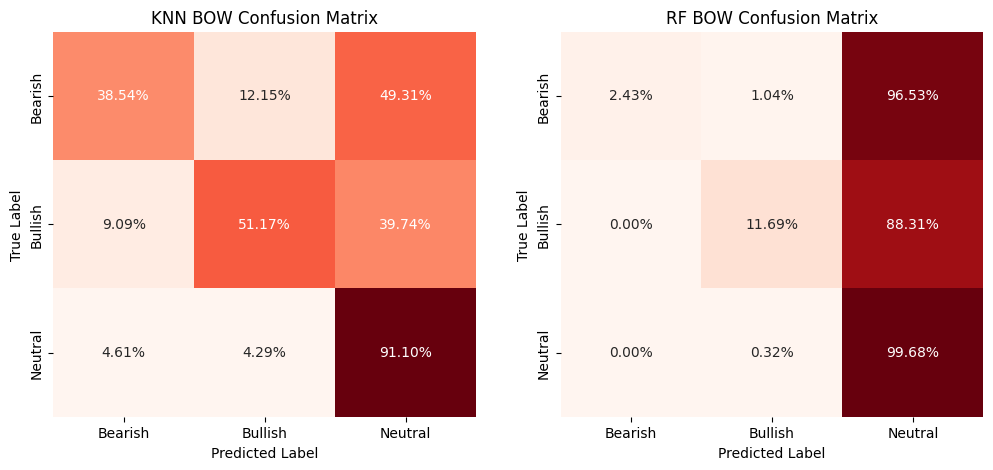

In [22]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.heatmap(knn_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[0]
            )
ax[0].set_title("KNN BOW Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(rf_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[1]
            )
ax[1].set_title("RF BOW Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.savefig("plots/bow_compare.png")
plt.show()

## Word2Vec

### KNN

In [23]:
best_score = -float("inf")
grid = {
        "n_neighbors": [*range(1, 16, 2)],
        "weights": ["uniform", "distance"],
        "p": [1, 2, 3]
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _knn = KNeighborsClassifier()
    _knn.set_params(**g)
    _knn.fit(train_vec, train_label)

    new_score = recall_score(validation_label, 
                             _knn.predict(validation_vec), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [00:47<00:00,  1.58s/it]

Best Recall: 0.47163
Grid: {'weights': 'distance', 'p': 2, 'n_neighbors': 1}


In [24]:
knn_classifier = KNeighborsClassifier()\
                .set_params(**best_grid)\
                .fit(train_vec, train_label)
knn_predicted = knn_classifier.predict(validation_vec)
knn_cm = confusion_matrix(validation_label, knn_predicted, normalize="true")

print(classification_report(validation_label, 
                            knn_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

              precision    recall  f1-score   support

     Bearish       0.26      0.27      0.27       288
     Bullish       0.40      0.39      0.39       385
     Neutral       0.75      0.75      0.75      1236

    accuracy                           0.61      1909
   macro avg       0.47      0.47      0.47      1909
weighted avg       0.61      0.61      0.61      1909



### Tree

In [25]:
best_score = -float("inf")
grid = {
        "n_estimators":[*range(10, 251, 10)], 
        "criterion":["gini", "entropy"],
        "max_depth":[*range(1, 11)],
        "min_samples_split":[2**p for p in range(1, 11)],
        "min_samples_leaf":[2**p for p in range(0, 11)],
        "max_features":["sqrt", "log2", 1],
        }

for g in tqdm.tqdm(ParameterSampler(grid, n_iter=30, random_state=SEED)):
    _rf = RandomForestClassifier()
    _rf.set_params(**g)
    _rf.fit(train_vec, train_label)

    new_score = recall_score(validation_label, 
                             _rf.predict(validation_vec), 
                             average="macro")
    # save if best
    if new_score > best_score:
        best_score = new_score
        best_grid = g

print("Best Recall: %0.5f" % best_score )
print("Grid:", best_grid)

100%|██████████| 30/30 [00:39<00:00,  1.33s/it]

Best Recall: 0.44229
Grid: {'n_estimators': 160, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'entropy'}


In [26]:
rf_classifier = RandomForestClassifier()\
                .set_params(**best_grid)\
                .fit(train_vec, train_label)

rf_predicted = rf_classifier.predict(validation_vec)
rf_cm = confusion_matrix(validation_label, rf_predicted, normalize="true")

print(classification_report(validation_label, 
                            rf_predicted, 
                            target_names=("Bearish", "Bullish", "Neutral")))

              precision    recall  f1-score   support

     Bearish       0.69      0.03      0.06       288
     Bullish       0.58      0.35      0.44       385
     Neutral       0.71      0.95      0.81      1236

    accuracy                           0.69      1909
   macro avg       0.66      0.45      0.44      1909
weighted avg       0.68      0.69      0.62      1909



### Compare

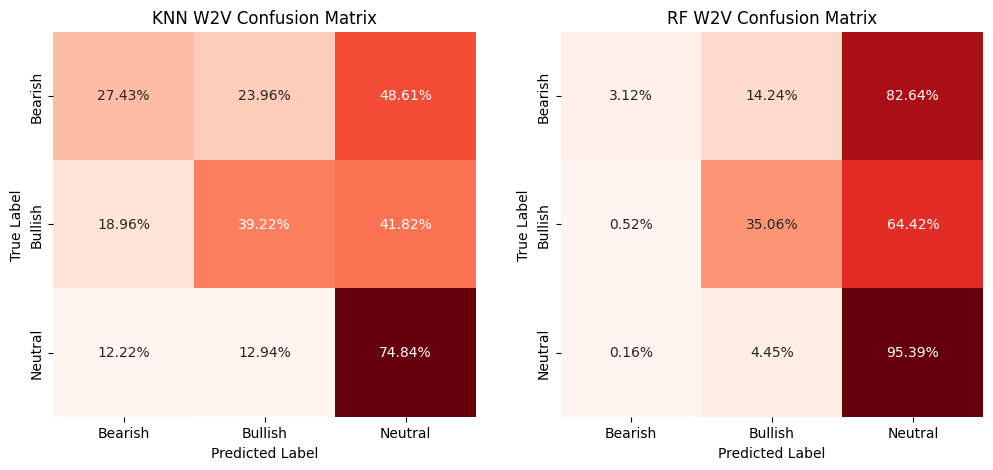

In [27]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.heatmap(knn_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[0]
            )
ax[0].set_title("KNN W2V Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(rf_cm,
            cmap="Reds",
            cbar=False,
            annot=True,
            fmt=".2%",
            xticklabels=("Bearish", "Bullish", "Neutral"), 
            yticklabels=("Bearish", "Bullish", "Neutral"),
            ax=ax[1]
            )
ax[1].set_title("RF W2V Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.savefig("plots/w2v_compare.png")
plt.show()